# Build Coupled Wflow-SFINCS Model

In [1]:
from os.path import join
import os
from pathlib import Path
import sys

os.environ.pop("DEBUG", None)
repo_root = next(
    base for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (base / "src").exists() and (base / "locations").exists()
)
src_root = repo_root / "src"
sys.path = [entry for entry in sys.path if entry != str(src_root)]
sys.path.insert(0, str(src_root))
for module_name in list(sys.modules):
    if module_name == "study_location" or module_name.startswith(("design_events", "sfincs_runs", "wflow_runs")):
        sys.modules.pop(module_name, None)

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from generated_artifact import write_generated_yaml
from hydromt_sfincs import DATADIR, SfincsModel

# create domains, handoff points, observations, and physics checks.
from sfincs_runs.build_base import (
    add_inland_outflow_boundary,
    build_domains,
    create_handoffs,
    plan_inland_sfincs_base,
    plan_inland_sfincs_domain_set,
    plot_sfincs_handoff_basemap,
    sfincs_grid_resolution_matches,
    sfincs_rivers_inflow_geoms,
    set_observations,
    validate_physics,
    write_inland_sfincs_domain_set_manifest,
)
# create native submodels and verify coupling inputs.
from wflow_runs import (
    coupled_domain_review,
    wflow_artifact_inventory,
    wflow_handoff_contract,
    build_wflow_data_catalog,
    build_wflow_submodel,
    validate_wflow_reservoir_staticmaps,
    plot_wflow_basemap,
    plot_wflow_ldd_components,
    wflow_catalog_source_readiness,
    write_wflow_domain_set_manifest,
)
# standard paths and readiness tables.
from wflow_runs.notebook import load_runtime, find_location_root, domain_summary, subbasins

def configread(path):
    with open(path, encoding="utf-8") as handle:
        return yaml.safe_load(handle)


In [2]:
# Load this Location Workspace.
runtime = load_runtime(find_location_root("austin", start=Path.cwd()), wflow_domain_review_required=True)
location_root = runtime.location_root
repo_root = runtime.repo_root
location_name = runtime.location_name
config = runtime.config
paths = runtime.design_paths

def location_path(value):
    return runtime.resolve_location_path(value)

build_wflow = True
build_all_wflow_submodels = True
write_wflow_catalog = True
write_domain_set_manifest = True
run_sfincs_domain_build = True

sfincs_data_catalog = location_root / "data/static/data_catalogue.yaml"
wflow_data_catalog = runtime.wflow_base_root.parent / "data_catalog.yml"
wflow_base_root = runtime.wflow_base_root
wflow_network_path = Path(paths["usgs_streamgage_network_geojson"])

data_cols = ["category", "crs", "data_type", "uri"]

## Rerun Control


In [3]:
rerun = True

## Part 1 — Coupled Domain Plans

Wflow and SFINCS use different geometry meanings: Wflow is hydrologic and can extend upstream; SFINCS is hydraulic coverage around each SMART-DS component.


### Step 1 · Wflow watershed and SFINCS coverage plans

Plan Wflow from the configured full-encapsulation hydrologic domain (`encompassing_huc`) and plan SFINCS from the selected SMART-DS coverage box. The Wflow HUC/HUC-union watershed supplies the upstream routing area; the SFINCS native river-inflow source IDs written here are the hydraulic coupling targets used later by Wflow gauges.


In [4]:
wflow_build_plan, wflow_domain_plan, domain_report = domain_summary(config, location_root)
sfincs_base_plan = plan_inland_sfincs_base(config, paths)
sfincs_domain_plan = plan_inland_sfincs_domain_set(config, paths)

if sfincs_domain_plan.status == "ready":
    sfincs_domain_manifest = write_inland_sfincs_domain_set_manifest(sfincs_domain_plan, config, paths)
else:
    sfincs_domain_manifest = None

write_domain_set_manifest = wflow_domain_plan.status == "ready"
if write_domain_set_manifest:
    wflow_domain_manifest = write_wflow_domain_set_manifest(wflow_domain_plan, config, paths)
else:
    wflow_domain_manifest = None

domain_set = yaml.safe_load(location_path(config["sfincs_domain_set"]["domain_manifest"]).read_text()) if sfincs_domain_manifest else {"domains": []}
sfincs_domains = list(domain_set["domains"])

display(domain_report)
display(subbasins(wflow_domain_plan))
display(pd.Series({
    "wflow_domain_status": wflow_domain_plan.status,
    "wflow_domain_manifest": str(wflow_domain_manifest.relative_to(repo_root)) if wflow_domain_manifest else "review_required",
    "sfincs_domain_status": sfincs_domain_plan.status,
    "sfincs_domain_manifest": str(sfincs_domain_manifest.relative_to(repo_root)) if sfincs_domain_manifest else "review_required",
    "sfincs_domain_count": sfincs_domain_plan.domain_count,
    "sfincs_handoff_count": sfincs_domain_plan.handoff_count,
}, name="domain_set_plans"))


allow_multiple_submodels                                     True
review_required                                              True
domain_status                    review_required_bbox_placeholder
reviewed_subbasin_plan_status                               ready
hydromt_region_kind                                          bbox
event_catalog_scope                      shared_across_domain_set
configured_submodel_count                                       0
reviewed_submodel_count                                         1
reviewed_handoff_count                                          8
domain_set_manifest                    data/wflow/domain_set.yaml
dtype: object

,wflow_submodel_id,hydromt_region_kind,hydromt_region,handoff_outlet_lon,handoff_outlet_lat,sfincs_domain_ids,sfincs_handoff_ids,gauge_site_nos,frequency_basis
0,austin_p5u,geom,{'geom': '/home/grahamhults/projects/Flood-RM/...,None,None,austin_p5u,"austin_p5u_inflow_01, austin_p5u_inflow_02, au...","08154700, 08155200, 08155240, 08155300, 081554...",austin_p5u


wflow_domain_status                                                   ready
wflow_domain_manifest           locations/austin/data/wflow/domain_set.yaml
sfincs_domain_status                                                  ready
sfincs_domain_manifest    locations/austin/data/sfincs/domains/domain_se...
sfincs_domain_count                                                       1
sfincs_handoff_count                                                      8
Name: domain_set_plans, dtype: object

### Step 2 · Hydrologic boundary and handoff map

Plot the selected Wflow watershed boundary, selected SMART-DS coverage, and planned stream/coverage-box handoff points before any model build. This is the hydrologic handoff check: Wflow owns the upstream watershed, while SFINCS owns only the hydraulic coverage box.


In [ ]:
domain_review = coupled_domain_review(
    config,
    location_root,
    sfincs_domains=sfincs_domains,
    wflow_domain_plan=wflow_domain_plan,
    figsize=(9, 7),
)

sfincs_domain_gdf = domain_review.sfincs_domain_gdf
wflow_watershed_gdf = domain_review.wflow_watershed_gdf
selected_study = domain_review.selected_study_gdf
handoff_plan_gdf = domain_review.handoff_plan_gdf

display(domain_review.summary)
plt.show()


## Part 2 — HydroMT-Wflow Native Build

Wflow is built first because its DEM/LDD-derived `staticgeoms/rivers.geojson` is the authoritative stream linework for SFINCS source placement.


### Step 3 · HydroMT-Wflow data catalog readiness

HydroMT-Wflow needs the local DEM-derived hydrography basemap, landcover, soil parameter maps, and event forcing sources before the submodels can be built.


In [6]:
wflow_catalog_path = build_wflow_data_catalog(config, paths) if write_wflow_catalog else wflow_data_catalog
wflow_source_readiness = pd.DataFrame(wflow_catalog_source_readiness(wflow_catalog_path))
missing_required_wflow_source = (
    wflow_source_readiness["required_for_build"].fillna(False).astype(bool)
    & wflow_source_readiness["local_file"].fillna(False).astype(bool)
    & ~wflow_source_readiness["exists"].fillna(False).astype(bool)
)
required_wflow_sources_missing = wflow_source_readiness[missing_required_wflow_source]

if not required_wflow_sources_missing.empty:
    missing_lines = [
        f"{row.source}: {row.uri}"
        for row in required_wflow_sources_missing.itertuples(index=False)
    ]
    display(wflow_source_readiness)
    raise FileNotFoundError(
        "Missing required HydroMT-Wflow source files before build:\n"
        + "\n".join(missing_lines)
        + "\nRun locations/austin/02_flood/01_region_setup.ipynb through the Terrain, Landcover, and Wflow static inputs cell first. "
        + "For a fresh Wflow static pull, launch that notebook with FLOOD_RM_FETCH_DEM=1; landcover fetch is enabled by default."
    )

wflow_source_readiness


,source,data_type,uri,local_file,exists,required_for_build,status,category
0,us_hydrography_basemap,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,review_required,hydrography
1,austin_streamgage_network,GeoDataFrame,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,hydrography
2,nhdplus_hr_river_geometry,GeoDataFrame,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,NaN,hydrography
3,nhdplus_hr_wflow_reservoirs,GeoDataFrame,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,review_required_public_waterbody_estimates,hydrography
4,esa_worldcover,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,NaN,landuse
5,ssurgo_hydrologic_soil_group,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,soils
6,ssurgo_saturated_conductivity,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,False,NaN,soils
7,ssurgo_wflow_soil_parameters,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,True,True,True,review_required,soils
8,event_precip,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,False,None,False,NaN,event_forcing
9,event_temp_pet,RasterDataset,/home/grahamhults/projects/Flood-RM/locations/...,False,None,False,NaN,event_forcing


### Step 4 · Wflow build steps

Inspect the HydroMT-Wflow workflow. `build_wflow_submodel` keeps this syntax but replaces the template region with the reviewed HUC/HUC-union watershed geometry and uses the native SFINCS river-inflow source points as handoff gauges.


In [7]:
wf_config = configread(str(location_path(config["wflow"]["build_config"])))
print(wf_config.keys())
pd.DataFrame({"step": [next(iter(step)) for step in wf_config.get("steps", [])]})


dict_keys(['steps'])


,step
0,setup_config
1,setup_basemaps
2,setup_rivers
3,setup_reservoirs_no_control
4,setup_lulcmaps
5,setup_soilmaps
6,setup_constant_pars
7,setup_gauges


### Step 5 · Build or reuse Wflow submodels

Each Wflow submodel is the configured hydrologic domain from `wflow.domain_set`; for Austin this is the full HUC/HUC-union watershed that encapsulates the selected SFINCS coverage. This first pass guarantees that HydroMT-Wflow-native rivers, basins, gauges, and static maps are available before SFINCS source placement.


In [8]:
if wflow_domain_plan.status != "ready":
    raise RuntimeError(f"Wflow Domain Set requires review before build: {wflow_domain_plan.status}: {wflow_domain_plan.issues}")
if sfincs_domain_plan.status != "ready":
    raise RuntimeError(f"SFINCS coverage domains require review before build: {sfincs_domain_plan.status}: {sfincs_domain_plan.issues}")

selected_submodels = wflow_domain_plan.submodels if build_all_wflow_submodels else wflow_domain_plan.submodels[:1]
reservoirs_enabled = bool(config.get("collection", {}).get("national_hydrography", {}).get("reservoirs", {}).get("enabled", False))
reservoir_preflight_rows = []
if reservoirs_enabled:
    for submodel in selected_submodels:
        submodel_id = submodel["wflow_submodel_id"]
        model_root = wflow_base_root / submodel_id
        staticmaps_path = model_root / "staticmaps.nc"
        if staticmaps_path.exists():
            report = validate_wflow_reservoir_staticmaps(model_root, required=True, raise_on_error=False)
            report.insert(0, "wflow_submodel_id", submodel_id)
            reservoir_preflight_rows.append(report)
    reservoir_preflight = pd.concat(reservoir_preflight_rows, ignore_index=True) if reservoir_preflight_rows else pd.DataFrame()
    display(reservoir_preflight)
    if not reservoir_preflight.empty and reservoir_preflight["status"].isin(["failed", "review_required"]).any() and not rerun:
        raise RuntimeError("Reservoirs are enabled, but the existing Wflow base is stale. Set rerun=True and rerun this step.")

wflow_native_build_summary = []
if build_wflow:
    for submodel in selected_submodels:
        submodel_id = submodel["wflow_submodel_id"]
        river_fn = wflow_base_root / submodel_id / "staticgeoms/rivers.geojson"
        wflow_native_build_summary.append(
            build_wflow_submodel(
                config,
                paths,
                submodel_id=submodel_id,
                force=rerun or not river_fn.exists(),
                write_catalog=False,
            )
            )

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_native_build_summary}
pd.DataFrame([{k: v for k, v in summary.items() if k != "model"} for summary in wflow_native_build_summary])


,wflow_submodel_id,check,status,message
0,austin_p5u,reservoir_area_id,passed,"reservoir_ids=[1, 3, 5, 6]; area_cells=12873"
1,austin_p5u,reservoir_outlet_id,passed,"outlet_ids=[1, 3, 5, 6]; outlet_cells=4; missi..."
2,austin_p5u,reservoir_initial_depth,passed,valid_cells=4; min=3.65882; max=16.9408
3,austin_p5u,meta_reservoir_mean_outflow,passed,valid_cells=4; min=0.01; max=9.09321
4,austin_p5u,reservoir_b,passed,valid_cells=4; min=0.000746997; max=0.363729
5,austin_p5u,reservoir_e,passed,valid_cells=4; min=2; max=2
6,austin_p5u,reservoir_rating_curve,passed,valid_cells=12873; min=-999; max=3
7,austin_p5u,reservoir_storage_curve,passed,valid_cells=12873; min=-999; max=1


2026-06-26 09:18:15,084 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/data_catalog.yml
2026-06-26 09:18:15,131 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-26 09:18:15,132 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-26 09:18:15,150 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-26 09:18:15,151 - hydromt.hydromt_wflow.components.config - config - INFO - Reading default config file from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/wflow_sbm/wflow_sbm.toml.
2026-06-26 09:18:15,153 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-26 09:18:15,154 - hydromt.model.model - mod

,status,wflow_submodel_id,base_model_root,data_catalog,gauges_fn,gauge_count,observation_gauges_fn,observation_gauge_count,built,staticmap_qa_status
0,built,austin_p5u,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,8,/home/grahamhults/projects/Flood-RM/locations/...,30,True,passed


### Step 6 · Wflow static map inventory

List the HydroMT-Wflow static maps and static geometries produced by `setup_basemaps`, `setup_rivers`, and `setup_gauges` before trusting any handoff point.


In [ ]:
wflow_inventory = wflow_artifact_inventory(
    config,
    location_root,
    selected_submodels=selected_submodels,
    wflow_models=wflow_models,
    wflow_base_root=wflow_base_root,
    repo_root=repo_root,
    load_staticmap_values=False,
)

display(wflow_inventory.native_handoffs)
if not wflow_inventory.reservoir_readiness.empty:
    display(wflow_inventory.reservoir_readiness)
wflow_inventory.inventory


### Step 7 · Wflow native basemap plots

Plot elevation, adaptive HydroMT-Wflow river vectors, basins, gauges, and SFINCS coverage boxes using the built Wflow model objects and their native `staticmaps` / `geoms` artifacts. Lower-order vector streams are only added where they intersect SFINCS domains so handoff crossings remain visible without plotting raster river cells.


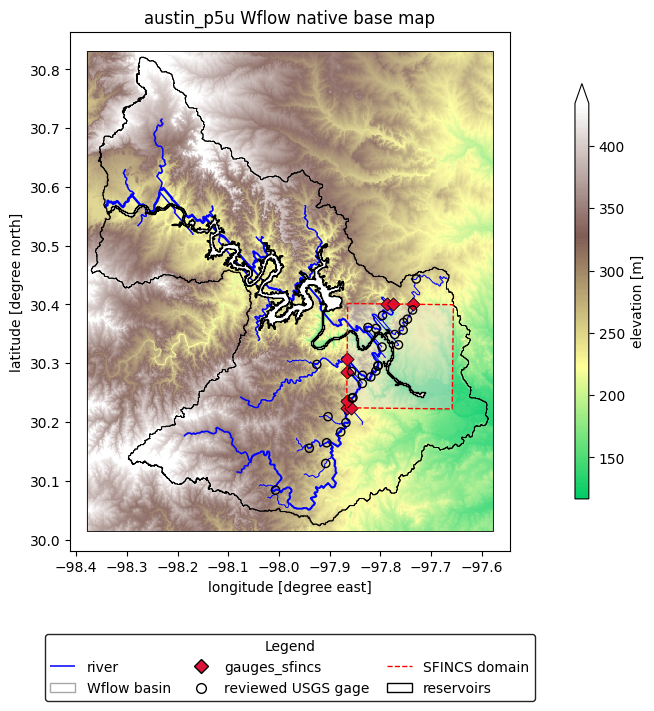

In [10]:
for submodel_id, wf in wflow_models.items():
    observation_gages_path = wflow_base_root.parent / "domain_set_gauges" / f"{submodel_id}_observation_gauges.geojson"
    observation_gages = gpd.read_file(observation_gages_path) if observation_gages_path.exists() else None
    fig, ax = plot_wflow_basemap(wf, gages=observation_gages, sfincs_domains=sfincs_domain_gdf, figsize=(9.5, 7.0), title=f"{submodel_id} Wflow native base map")
    fig.savefig(wflow_base_root / submodel_id / "wflow_native_basemap.png", dpi=450, bbox_inches="tight")


### Step 8 · Wflow LDD component plots

Inspect the flow-aware layers that control handoff placement: elevation, upstream area, stream order, and local drain direction.


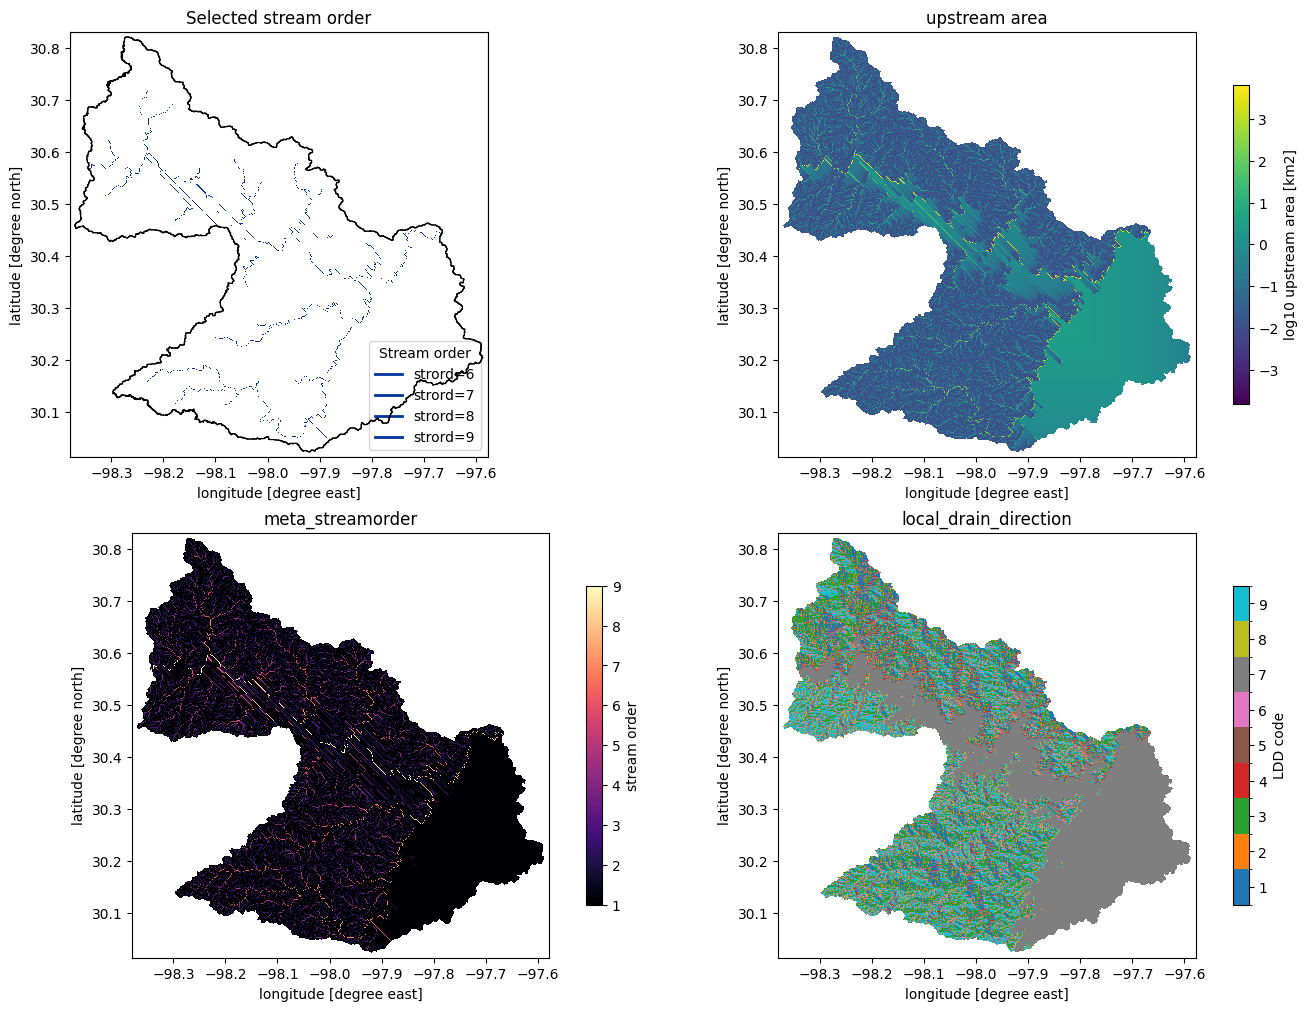

In [11]:
for submodel_id, wf in wflow_models.items():
    fig, _ = plot_wflow_ldd_components(wf)
    fig.savefig(wflow_base_root / submodel_id / "wflow_ldd_components_native.png", dpi=300, bbox_inches="tight")


## Part 3 — HydroMT-SFINCS Coverage Build

SFINCS domains are hydraulic coverage boxes around SMART-DS components. They are not assumed to be full watersheds.


### Step 9 · Initialize SFINCS coverage models

Each SMART-DS coverage box gets its own `SfincsModel` root. The discharge sources are added after Wflow-native rivers are available.


In [12]:
sfincs_models = {}
sfincs_model_rows = []

for domain in sfincs_domains:
    sfincs_domain_id = domain["sfincs_domain_id"]
    root = location_path(domain["base_model_root"])
    expected_sfincs_res_m = float(config["sfincs"]["grid_resolution_m"])
    sfincs_model_resolution_ready = sfincs_grid_resolution_matches(root, expected_sfincs_res_m)
    sfincs_model_ready = (root / "sfincs.inp").exists() and sfincs_model_resolution_ready
    sfincs_model_mode = "w+" if rerun or not sfincs_model_ready else "r+"
    if sfincs_model_mode == "w+" and not run_sfincs_domain_build:
        raise FileNotFoundError(
            f"SFINCS base model is missing for {sfincs_domain_id}: {root}. "
            "Set run_sfincs_domain_build=True before opening a new coverage model."
        )
    sf = SfincsModel(
        root=str(root),
        mode=sfincs_model_mode,
        data_libs=[str(sfincs_data_catalog), str(wflow_data_catalog)],
        )
    sfincs_models[sfincs_domain_id] = sf
    sfincs_model_rows.append({
        "sfincs_domain_id": sfincs_domain_id,
        "region": str(location_path(domain["region"]).relative_to(repo_root)),
        "base_model_root": str(root.relative_to(repo_root)),
        "model_ready": sfincs_model_ready,
        "model_mode": sfincs_model_mode,
        "grid_resolution_m": expected_sfincs_res_m,
        "existing_grid_matches_resolution": sfincs_model_resolution_ready,
        "handoff_source_count": len(domain["handoff_source_ids"]),
    })

sf_data = ["dem_region", "landcover_region", "hydrologic_soil_group", "saturated_conductivity"]
display(next(iter(sfincs_models.values())).data_catalog._to_dataframe().loc[sf_data, data_cols])
pd.DataFrame(sfincs_model_rows)


2026-06-26 09:20:09,478 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/austin/data/static/data_catalogue.yaml
2026-06-26 09:20:09,486 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/data_catalog.yml
2026-06-26 09:20:09,496 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 09:20:09,497 - hydromt.model.model - model - WARNING - No region component found in components.


,category,crs,data_type,uri
name,,,,
dem_region,topography,4269.0,RasterDataset,processed/dem_region_setup.tif
landcover_region,landuse,4269.0,RasterDataset,processed/landcover_region_setup.tif
hydrologic_soil_group,soils,4269.0,RasterDataset,soils/hsg_austin.tif
saturated_conductivity,soils,4269.0,RasterDataset,soils/ksat_mmhr_austin.tif


,sfincs_domain_id,region,base_model_root,model_ready,model_mode,grid_resolution_m,existing_grid_matches_resolution,handoff_source_count
0,austin_p5u,locations/austin/data/sfincs/domains/austin_p5...,locations/austin/data/sfincs/domains/austin_p5...,True,w+,60.0,True,8


### Step 10 · SFINCS build configuration

Use the standard HydroMT-SFINCS build recipe for the grid, elevation, masks, and subgrid. The Wflow coupling sources are then created with HydroMT-SFINCS native river inflow tooling from the Wflow hydrography catalog.


In [13]:
sf_config_path = location_path(config["sfincs"]["build_config"])
sf_recipe = (config.get("_model_recipes") or {}).get("sfincs_build")
if sf_recipe is not None:
    sf_config_path.parent.mkdir(parents=True, exist_ok=True)
    write_generated_yaml(sf_config_path, sf_recipe, source="the sfincs_build model YAML extraction")
sf_config = configread(str(sf_config_path))
sf_config["setup_grid_from_region"]["res"] = config["sfincs"]["grid_resolution_m"]
sf_config["setup_grid_from_region"]["crs"] = config["sfincs"].get("model_crs", config["project"]["model_crs"])
sf_config["setup_dep"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_rgh"] = [{"lulc": "landcover_region"}]
sf_config.pop("setup_river_outflow", None)
print(sf_config.keys())


dict_keys(['setup_grid_from_region', 'setup_dep', 'setup_mask_active', 'setup_mask_bounds', 'setup_subgrid'])


### Step 11 · Build or reuse SFINCS grids, masks, subgrid, and Wflow source points

The source GeoJSON is written after the SFINCS grid exists so HydroMT-SFINCS can place discharge points where river centerlines enter the hydraulic domain. Wflow then uses those SFINCS `src` points as its handoff gauges.


In [14]:
sfincs_build_report = pd.DataFrame()
if run_sfincs_domain_build:
    sfincs_build_report = build_domains(
        config,
        paths,
        force=rerun,
    )

sfincs_models = {}
sfincs_build_rows = []
handoff_layers = []

for domain in sfincs_domains:
    domain_id = domain["sfincs_domain_id"]
    root = location_path(domain["base_model_root"])
    validate_physics(root, config)

    sf = SfincsModel(
        root=str(root),
        mode="r+",
        data_libs=[str(sfincs_data_catalog), str(wflow_data_catalog)],
    )
    sf.read()
    sfincs_models[domain_id] = sf

    handoff_locations = root / "gis/wflow_handoff_sources.geojson"
    create_handoffs(
        sf,
        config,
        paths,
        output=handoff_locations,
        sfincs_domain_id=domain_id,
        wflow_submodel_id=next(iter(domain.get("wflow_submodel_ids", [])), None),
        handoff_source_ids=domain.get("handoff_source_ids", ()),
    )
    sf.write()
    src = gpd.read_file(handoff_locations)
    rivers = sfincs_rivers_inflow_geoms(sf)
    handoff_layers.append(src)
    sfincs_build_rows.append({
        "sfincs_domain_id": domain_id,
        "built": domain_id in set(sfincs_build_report.get("sfincs_domain_id", [])),
        "grid_resolution_m": float(config["sfincs"]["grid_resolution_m"]),
        "rivers_inflow_features": int(len(rivers)),
        "root": str(root.relative_to(repo_root)),
    })

pd.DataFrame(sfincs_build_rows)


2026-06-26 09:20:09,594 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 09:20:09,596 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-26 09:20:09,601 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading region.geojson GeoDataFrame data from /home/grahamhults/projects/Flood-RM/locations/austin/data/sfincs/domains/austin_p5u/region.geojson
2026-06-26 09:20:09,621 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 9 attributes in model config.
2026-06-26 09:20:09,654 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading dem_region RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/dem_region_setup.tif
2026-06-26 09:20:09,674 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - RasterDataset: CRS from data catalog does not match CRS  of data. The original

2026-06-26 09:20:10,548 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - WARNING - nan values in manning roughness array
2026-06-26 09:20:10,599 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - INFO - Set other manning options to None in config that are unused in SFINCS in case of specifying manningfile (manning, manning_land, manning_sea, rgh_lev_land).
2026-06-26 09:20:10,607 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading dem_region RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/dem_region_setup.tif
2026-06-26 09:20:10,624 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - RasterDataset: CRS from data catalog does not match CRS  of data. The original CRS will be used. Please check your catalog.
2026-06-26 09:20:10,632 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading landcover_region RasterDataset data from /home/grahamhults/pro

,sfincs_domain_id,built,grid_resolution_m,rivers_inflow_features,root
0,austin_p5u,True,60.0,23,locations/austin/data/sfincs/domains/austin_p5...


### Step 12 · SFINCS coverage QA plots

Plot each SFINCS coverage grid with reviewed gages, HydroMT-SFINCS native `rivers_inflow` linework, and Wflow->SFINCS source points.


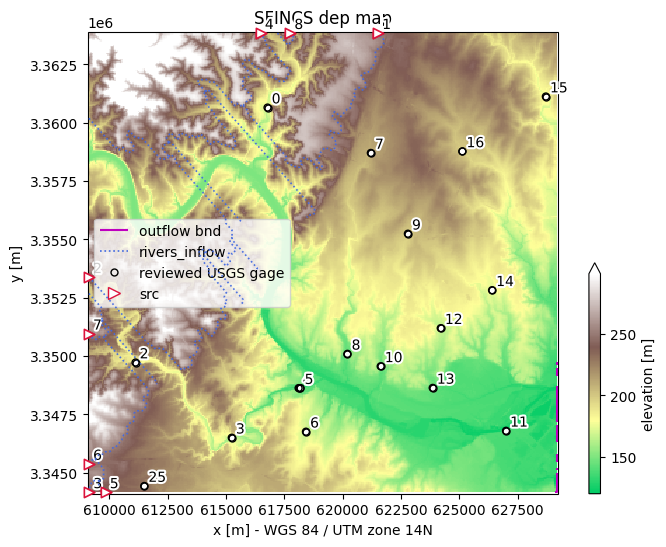

In [15]:
handoff_gdf = pd.concat(handoff_layers, ignore_index=True)
handoff_gdf = gpd.GeoDataFrame(handoff_gdf, geometry="geometry", crs=handoff_layers[0].crs)

for domain in sfincs_domains:
    domain_id = domain["sfincs_domain_id"]
    sf = sfincs_models[domain_id]
    sf.elevation.data["dep"].attrs.update(long_name="elevation", units="m")
    handoff_locations = location_path(domain["base_model_root"]) / "gis/wflow_handoff_sources.geojson"
    rivers = sfincs_rivers_inflow_geoms(sf)
    observations = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs=sf.crs)
    if wflow_network_path.exists():
        observations = set_observations(sf, wflow_network_path)
    fig, ax, plot_qa = plot_sfincs_handoff_basemap(
        sf,
        handoff_sources=handoff_locations,
        rivers=rivers,
        observations=observations,
        config=config,
        paths=paths,
        domain_region=domain["region"],
        figsize=(8, 6),
    )
    fig.savefig(join(sf.root.path, "sfincs_basemap.png"), dpi=450, bbox_inches="tight")


### Step 13 · SFINCS handoff source table

Review the source coordinates and their river-intersection provenance before rebuilding Wflow gauges.


In [16]:
handoff_columns = [
    "sfincs_domain_id",
    "sfincs_handoff_id",
    "wflow_submodel_id",
    "site_no",
    "handoff_placement",
    "handoff_location_review_status",
    "stream_boundary_river_source",
    "stream_boundary_candidate_count",
]
handoff_columns = [column for column in handoff_columns if column in handoff_gdf.columns]
handoff_gdf[handoff_columns]


,sfincs_domain_id,sfincs_handoff_id,wflow_submodel_id,site_no,handoff_placement,handoff_location_review_status,stream_boundary_river_source
0,austin_p5u,austin_p5u_inflow_01,austin_p5u,austin_p5u_inflow_01,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
1,austin_p5u,austin_p5u_inflow_02,austin_p5u,austin_p5u_inflow_02,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
2,austin_p5u,austin_p5u_inflow_03,austin_p5u,austin_p5u_inflow_03,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
3,austin_p5u,austin_p5u_inflow_04,austin_p5u,austin_p5u_inflow_04,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
4,austin_p5u,austin_p5u_inflow_05,austin_p5u,austin_p5u_inflow_05,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
5,austin_p5u,austin_p5u_inflow_06,austin_p5u,austin_p5u_inflow_06,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
6,austin_p5u,austin_p5u_inflow_07,austin_p5u,austin_p5u_inflow_07,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap
7,austin_p5u,austin_p5u_inflow_08,austin_p5u,austin_p5u_inflow_08,sfincs_native_river_inflow,hydromt_sfincs_native_river_inflow,us_hydrography_basemap


## Part 4 — Coupling Back Into Wflow

After SFINCS writes boundary source points, Wflow is rebuilt with gauge outputs at exactly those source points. Each Wflow hydrologic domain may be much larger than its SFINCS coverage box.


### Step 14 · Rebuild Wflow gauges at SFINCS boundary sources

This second Wflow pass keeps the same HydroMT-Wflow hydrologic domains and static maps, but the `setup_gauges` SFINCS layer now reads the SFINCS boundary-source GeoJSONs.


In [17]:
wflow_build_summary = []
if build_wflow:
    for submodel in selected_submodels:
        wflow_build_summary.append(
            build_wflow_submodel(
                config,
                paths,
                submodel_id=submodel["wflow_submodel_id"],
                force=rerun,
                write_catalog=False,
            )
            )

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_build_summary}
pd.DataFrame([{k: v for k, v in summary.items() if k != "model"} for summary in wflow_build_summary])


2026-06-26 09:20:48,415 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/data_catalog.yml
2026-06-26 09:20:48,426 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-26 09:20:48,426 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-26 09:20:48,444 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-26 09:20:48,445 - hydromt.hydromt_wflow.components.config - config - INFO - Reading default config file from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/wflow_sbm/wflow_sbm.toml.
2026-06-26 09:20:48,448 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-26 09:20:48,449 - hydromt.model.model - mod

,status,wflow_submodel_id,base_model_root,data_catalog,gauges_fn,gauge_count,observation_gauges_fn,observation_gauge_count,built,staticmap_qa_status
0,built,austin_p5u,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,8,/home/grahamhults/projects/Flood-RM/locations/...,30,True,passed


### Step 15 · Final coupled Wflow basemaps

Plot the native Wflow model with filled Wflow basin and SFINCS coverage areas, Wflow-native river vectors, and the model's `gauges_sfincs` layer. This is the main check that the upstream Wflow model feeds the right hydraulic coverage box boundaries.


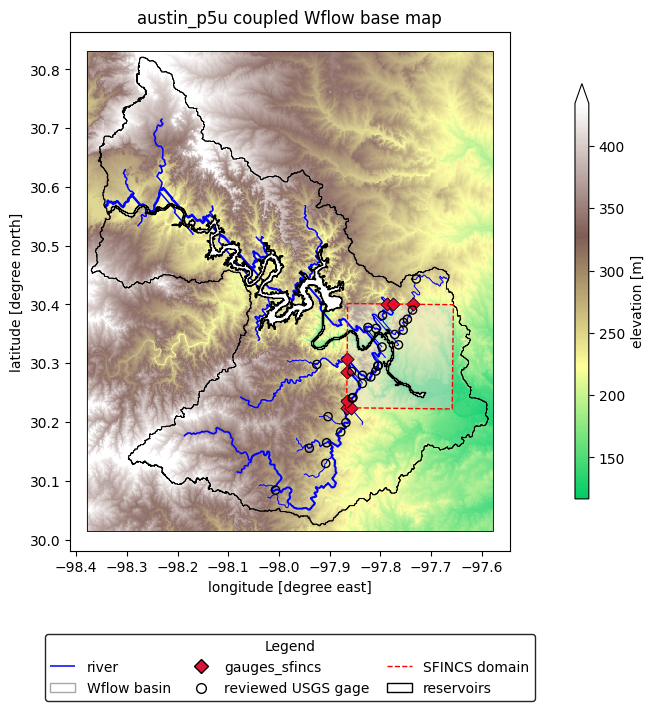

In [18]:
sfincs_background_elevation = [sf.elevation.data["dep"] for sf in sfincs_models.values()]
for submodel_id, wf in wflow_models.items():
    observation_gages_path = wflow_base_root.parent / "domain_set_gauges" / f"{submodel_id}_observation_gauges.geojson"
    observation_gages = gpd.read_file(observation_gages_path) if observation_gages_path.exists() else None
    fig, ax = plot_wflow_basemap(
        wf,
        gages=observation_gages,
        sfincs_domains=sfincs_domain_gdf,
        background_elevation=sfincs_background_elevation,
        figsize=(9.5, 7.0),
        title=f"{submodel_id} coupled Wflow base map",
    )
    fig.savefig(wflow_base_root / submodel_id / "wflow_basemap.png", dpi=450, bbox_inches="tight")


### Step 16 · Final Wflow gauge QA

List the Wflow gauge layers that will produce discharge for SFINCS and verify each SFINCS source maps to one nearby Wflow gauge. The LDD/staticmaps are not replotted here because gauge insertion does not change them.


In [ ]:
handoff_review = wflow_handoff_contract(
    config,
    location_root,
    wflow_models=wflow_models,
    handoff_gdf=handoff_gdf,
    wflow_base_root=wflow_base_root,
)

handoff_contract = handoff_review.handoff_contract
display(handoff_contract)
handoff_review.gauge_layers
